In [ ]:
from pathlib import Path
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import RCP_analysis as rcp
import numpy as np
from scipy.signal import find_peaks, fftconvolve
from spikeinterface.sortingcomponents.peak_detection import detect_peaks
import spikeinterface as si

# ------------ USER INPUTS ------------
FILE = Path('/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/Nike_UA_S2/Blackrock/Nike_UA_S2_003')

REPO_ROOT = Path().resolve().parents[2]
PARAMS    = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE  = SESSION_LOC / "results"; OUT_BASE.mkdir(parents=True, exist_ok=True)
BR_ROOT = SESSION_LOC / "Blackrock"; BR_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_CSV  = METADATA_ROOT / f"{Path(PARAMS.session)}_metadata.csv"
SHIFT_CSV = METADATA_ROOT / "br_to_intan_shifts.csv"

BR_SESSION_FOLDERS = rcp.list_br_sessions(BR_ROOT)

RATES = PARAMS.UA_rate_est
BIN_MS     = float(RATES.get("bin_ms", 20.0))
SIGMA_MS   = float(RATES.get("sigma_ms", 20.0))
THRESH     = float(RATES.get("detect_threshold", 3))
PEAK_SIGN  = str(RATES.get("peak_sign", "both"))

ARTREMV_MS_BEFORE = 5.0
ARTCORR_TAIL_MS   = 5.0
    
XLS = rcp.ua_excel_path(REPO_ROOT, PARAMS.probes)
UA_MAP = rcp.load_UA_mapping_from_excel(XLS) if XLS else None
if UA_MAP is None:
    raise RuntimeError("UA mapping required for mapping on NS6.")

# Sync channels
UA_CFG = PARAMS.probes.get("UA")
CAMERA_SYNC_CH = int(UA_CFG.get("camera_sync_ch", 134))
TRIANGLE_SYNC_CH = int(UA_CFG.get("triangle_sync_ch", 138))

UA_AUX_DATA = OUT_BASE / "aux_data" / "UA"
NPRW_AUX_DATA = OUT_BASE / "aux_data" / "NPRW"
UA_CKPT_OUT = OUT_BASE / "checkpoints" / "UA"; UA_CKPT_OUT.mkdir(parents=True, exist_ok=True)
NPRW_CKPT_ROOT = OUT_BASE / "checkpoints" / "NPRW"

# global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
# si.set_global_job_kwargs(**global_job_kwargs)

print(f"=== Session: {FILE.name} ===")
rec_ns6 = se.read_blackrock(FILE, stream_name = 'nsx6', all_annotations=True) # Load neural data

br_idx = int(FILE.name.split('_')[-1]) # resolve br index
n_channels = rec_ns6.get_num_channels()

rec_ns6, idx_rows, ua_elec, ua_nsp, ua_region, ua_region_names, _ = rcp.apply_ua_mapping_with_regions(rec_ns6, UA_MAP, br_idx, METADATA_CSV)
UA_probe = ua_region.copy()

rec_hp  = spre.highpass_filter(rec_ns6, freq_min=float(PARAMS.highpass_hz))
region_idx, elec_count = np.unique(UA_probe, return_counts=True)
print(" | ".join(f"{ua_region_names[v]}: {c}" for v, c in zip(region_idx, elec_count)))

=== Session: Nike_UA_S2_003 ===
[MAP] UA port from metadata: 'A'
[MAP] renamed 128/128 rows with UA mapping ('UAe###_NSP###') using port 'A'.
SMA: 30 | Dorsal premotor: 32 | M1 inferior: 31 | M1 superior: 35


In [39]:
def _dedup_peaks(
    peaks, fs: float,
    dedup_ms: float = 0.5,
    max_cluster_ms: float = 1.0,
    ch_field="channel_index",
    samp_field="sample_index",
    seg_field="segment_index",
    amp_field="amplitude",
):
    """Deduplicate peaks per (segment, channel), keeping strongest within short windows"""
    # Build keys
    peak_seg = peaks[seg_field] if seg_field in peaks.dtype.names else np.zeros(peaks.shape[0])
    peak_ch  = peaks[ch_field].astype(np.int32,  copy=False)
    peak_t   = peaks[samp_field].astype(np.int64, copy=False)
    peak_amp = np.abs(peaks[amp_field].astype(np.float32)) if amp_field in peaks.dtype.names else np.zeros(len(peaks))
    # Use abs because looking for largest peak

    # Sort by (segment, channel, time) to get the correct vectors
    order = np.lexsort((peak_t, peak_ch, peak_seg))
    peak_seg_ordered, peak_ch_ordered, peak_t_ordered, peak_amp_ordered = peak_seg[order], peak_ch[order], peak_t[order], peak_amp[order]
    peaks = peaks[order]

    keep = np.zeros(len(peaks), dtype=bool) # Create mask to remove dup spikes

    dedup_samp = max(1, int(round(dedup_ms * 1e-3 * fs)))
    max_cluster_samp = int(round(max_cluster_ms * 1e-3 * fs))

    for seg in np.unique(peak_seg_ordered):
        seg_mask = peak_seg_ordered == seg # Mask peaks in segment
        for ch in np.unique(peak_ch_ordered[seg_mask]):
            mask = seg_mask & (peak_ch_ordered == ch)
            idxs = np.where(mask)[0]
            if idxs.size == 0:
                continue

            t_local = peak_t_ordered[idxs]
            a_local = peak_amp_ordered[idxs]

            cluster_start = 0 # index counter
            for i in range(1, len(idxs)):
                isi = t_local[i] - t_local[i - 1]
                if isi > dedup_samp or (t_local[i] - t_local[cluster_start]) > max_cluster_samp: # If isi violation or cluster too big has to be between 0.5ms (ISI violation) or max threshold: 1 ms (could be another MUA)
                    cluster_slice = slice(cluster_start, i) # Get spikes
                    best = idxs[cluster_slice.start + np.argmax(a_local[cluster_slice])] # Find max and give index
                    keep[best] = True # Keep this spike
                    cluster_start = i

            # finalize last cluster
            cluster_slice = slice(cluster_start, len(idxs))
            best = idxs[cluster_slice.start + np.argmax(a_local[cluster_slice])]
            keep[best] = True

    return peaks[keep]

def _compute_peak_times_per_seg(
    peaks, recording, fs: float,
    n_seg: int,
    samp_field="sample_index",
    seg_field="segment_index",
):
    seg_n_samps = np.array([int(recording.get_num_frames(s)) for s in range(n_seg)], int)
    seg_offsets_samp = np.cumsum([0] + seg_n_samps[:-1].tolist()).astype(np.int64)

    if seg_field in peaks.dtype.names:
        seg_idx = peaks[seg_field].astype(np.int32, copy=False)
    else:
        if n_seg != 1:
            raise RuntimeError("No segment field in peaks for multi-segment recording.")
        seg_idx = np.zeros(peaks.shape[0], int)

    peak_samp_global = peaks[samp_field].astype(np.int32, copy=False) + seg_offsets_samp[seg_idx]
    peak_t_ms = peak_samp_global.astype(np.float32) * (1000.0 / fs)
    return seg_n_samps, peak_t_ms

def _bin_counts_and_masks_artrmv(
    peaks, seg_n_samps, n_ch, n_seg,
    fs, bin_ms, blank_windows_samples,
    ch_field="channel_index",
    samp_field="sample_index",
    seg_field="segment_index",
):
    bin_samps = int(round(bin_ms * 1e-3 * fs))
    counts_all, t_all, blank_masks = [], [], []
    bin_offset = 0

    for seg in range(n_seg):
        n_samps = seg_n_samps[seg]
        seg_bins = int(np.ceil(n_samps / bin_samps))
        counts = np.zeros((n_ch, seg_bins))

        if seg_field in peaks.dtype.names:
            seg_peaks = peaks[peaks[seg_field] == seg]
        else:
            seg_peaks = peaks if n_seg == 1 else None
            if seg_peaks is None:
                raise RuntimeError("No segment field in peaks for multi-segment recording.")

        if seg_peaks.size > 0:
            bins = np.clip(seg_peaks[samp_field] // bin_samps, 0, seg_bins - 1)
            np.add.at(counts, (seg_peaks[ch_field], bins), 1)

        counts_all.append(counts)

        blank_mask_seg = np.zeros(seg_bins, dtype=bool)
        if blank_windows_samples is not None and seg in blank_windows_samples:
            win = np.asarray(blank_windows_samples[seg], dtype=np.int32)
            win = win[(win[:, 1] > win[:, 0]) & (win[:, 0] < n_samps) & (win[:, 1] > 0)]
            if win.size:
                b0 = np.clip(win[:, 0] // bin_samps, 0, seg_bins)
                b1 = np.clip((win[:, 1] + bin_samps) // bin_samps, 0, seg_bins)
                for i0, i1 in zip(b0, b1):
                    blank_mask_seg[i0:i1] = True
        blank_masks.append(blank_mask_seg)

        t_ms = (np.arange(seg_bins, dtype=np.float32) + 0.5 + bin_offset) * bin_ms
        t_all.append(t_ms)
        bin_offset += seg_bins

    counts_cat = np.concatenate(counts_all, axis=1)
    t_cat_ms   = np.concatenate(t_all)
    blank_mask = np.concatenate(blank_masks) if blank_masks else np.zeros(counts_cat.shape[1], bool)

    return counts_cat, t_cat_ms, blank_mask

def _gauss_kernel_normalized(sigma_bins: float, radius_mult: float = 4.0):
    sigma_bins = max(1e-9, float(sigma_bins))
    r = int(np.ceil(radius_mult * sigma_bins))
    x = np.arange(-r, r+1, dtype=float)
    k = np.exp(-(x**2) / (2.0 * sigma_bins**2))
    k /= k.sum()
    return k

def _smooth_counts_with_blanks(counts_cat, blank_mask, sigma_ms, bin_ms):
    fs_bins = 1000.0 / float(bin_ms)

    if counts_cat.shape[1] < 4:
        counts_smooth = counts_cat.astype(float, copy=False)
        if blank_mask.any():
            counts_smooth[:, blank_mask] = np.nan
        return counts_smooth * fs_bins

    sigma_bins = float(sigma_ms) / float(bin_ms)
    k = _gauss_kernel_normalized(max(1e-9, sigma_bins), radius_mult=4.0)
    r = (k.size - 1) // 2

    X = counts_cat.astype(float, copy=False)
    valid0 = np.isfinite(X)

    if blank_mask.any():
        pad = np.zeros(r)
        dil = np.convolve(np.r_[pad, blank_mask.astype(int), pad],
                          np.ones(2 * r + 1, dtype=int), mode="same") > 0
        blank_dil = dil[r:-r]
    else:
        blank_dil = np.zeros(X.shape[1], dtype=bool)

    valid = valid0 & (~blank_dil)

    def _interp_short_gaps(y: np.ndarray, max_gap: int) -> np.ndarray:
        out = y.copy()
        isn = ~np.isfinite(out)
        if not isn.any():
            return out
        starts = np.where(isn & ~np.r_[False, isn[:-1]])[0]
        ends   = np.where(isn & ~np.r_[isn[1:],  False])[0]
        for s, e in zip(starts, ends):
            gap = e - s + 1
            L, R = s - 1, e + 1
            if gap <= max_gap and L >= 0 and R < out.size and np.isfinite(out[L]) and np.isfinite(out[R]):
                out[s:e+1] = np.interp(np.arange(s, e+1), [L, R], [out[L], out[R]])
        return out

    X_filled = X.copy()
    hard_nan = ~valid0
    for i in range(X.shape[0]):
        xi = X_filled[i]
        xi[blank_dil] = np.nan
        X_filled[i] = _interp_short_gaps(xi, r)

    Xp = np.pad(np.where(valid, X_filled, 0.0), ((0, 0), (r, r)), mode="reflect")
    Wp = np.pad(valid.astype(float),          ((0, 0), (r, r)), mode="reflect")

    num = fftconvolve(Xp, k[None, :], mode="same")[:, r:-r]
    den = fftconvolve(Wp, k[None, :], mode="same")[:, r:-r]

    counts_smooth = num / np.clip(den, 1e-12, None)
    counts_smooth[:, blank_mask] = np.nan

    return counts_smooth * fs_bins

## This function is used by Intan too
def threshold_mua_rates(
    recording,
    detect_threshold: float,
    peak_sign: str,
    bin_ms: float,
    sigma_ms: float,
    n_jobs: int,
    blank_windows_samples: dict[int, np.ndarray] | None = None,
):
    """
    Threshold-crossing MUA, binned, Gaussian-smoothed firing rates.

    Returns
    -------
    rate_hz : (n_channels, n_bins)
    t_ms    : (n_bins,)   # bin-center times in ms (concatenated across segments)
    counts  : (n_channels, n_bins)
    peaks   : np.ndarray  # structured array from SpikeInterface
    peak_t_ms : (n_peaks,) Global peak times in ms (segment offsets applied)
    """

    fs = recording.get_sampling_frequency()
    n_ch = recording.get_num_channels()
    n_seg = recording.get_num_segments()

    bin_samps = int(bin_ms * 1e-3 * fs)
    if bin_samps < 1:
        raise ValueError("bin_ms too small for sampling rate")

    # Detect peaks
    noise_levels = si.get_noise_levels(recording, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation

    print(f"[INFO] Spike bin size: {bin_samps / 30}ms, Average noise level: {np.nanmean(noise_levels)}")
    peaks = detect_peaks(
        recording,
        method="by_channel_torch",
        detect_threshold=detect_threshold,
        peak_sign=peak_sign,
        noise_levels=noise_levels,
        n_jobs=n_jobs,
    )
    
    # Build keys
    ch_field, samp_field, seg_field, amp_field = ("channel_index", "sample_index", "segment_index", "amplitude")    
    peaks = _dedup_peaks(peaks, fs, ch_field=ch_field, samp_field=samp_field,
                     seg_field=seg_field, amp_field=amp_field)

    # This is just in case there are multiple segments in the future, calculate absolute peak times
    seg_n_samps, peak_t_ms = _compute_peak_times_per_seg(peaks, recording, fs, n_seg, samp_field, seg_field)

    # 
    counts_cat, t_cat_ms, blank_mask = _bin_counts_and_masks_artrmv(
        peaks, seg_n_samps, n_ch, n_seg, fs, bin_ms, blank_windows_samples,
        ch_field, samp_field, seg_field,
    )

    rate_hz = _smooth_counts_with_blanks(counts_cat, blank_mask, sigma_ms, bin_ms)
    return rate_hz.astype(np.float32), t_cat_ms, counts_cat.astype(np.uint32), peaks, peak_t_ms

In [40]:
# compute rates
rate_hz, t_cat_ms, counts_cat, ua_peaks_ms, peaks_t_ms = threshold_mua_rates(
    rec_hp,
    detect_threshold=THRESH,
    peak_sign=PEAK_SIGN,
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
    n_jobs=PARAMS.parallel_jobs,
    blank_windows_samples=None,
)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Spike bin size: 20.0ms, Average noise level: 26.841181140613234


detect peaks using by_channel_torch (workers: 8 processes):   0%|          | 0/522 [00:00<?, ?it/s]

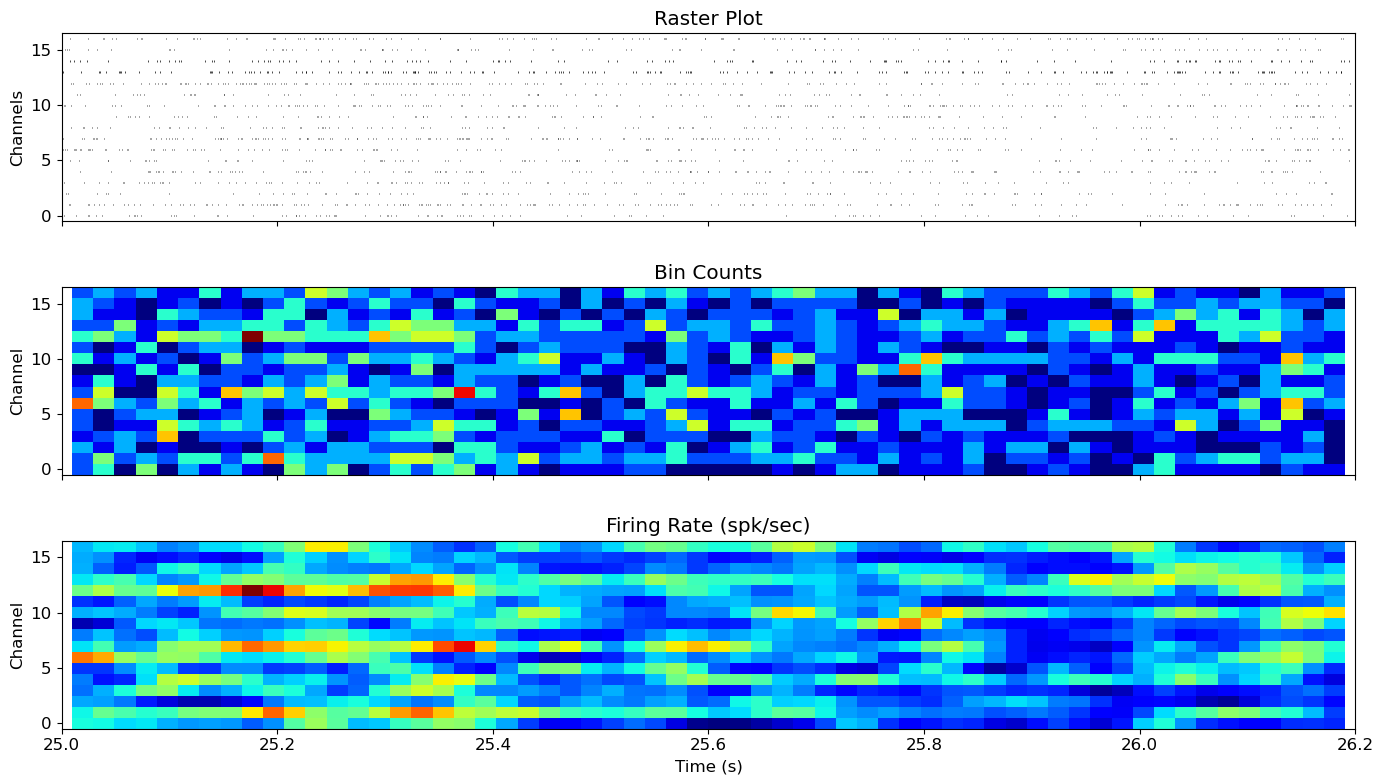

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# -------- window (in seconds) --------
T_START_S = 25        # start time of the window (s)
WIN_LEN_S = 1.2        # length of the window (s)

T_START_MS = T_START_S * 1000.0
T_END_MS   = (T_START_S + WIN_LEN_S) * 1000.0

N_CH_PLOT = 17
ch_idx = np.arange(N_CH_PLOT)

# -------- rate & counts window --------
time_mask = (t_cat_ms >= T_START_MS) & (t_cat_ms <= T_END_MS)
t_plot_s  = t_cat_ms[time_mask] / 1000.0                 # ms -> s in window

rate_plot   = rate_hz[ch_idx][:, time_mask]              # (channels, timebins)
counts_plot = counts_cat[ch_idx][:, time_mask]           # raw bin counts

# -------- spike window --------
chan_field = "channel_index"

spike_mask    = (
    (peaks_t_ms >= T_START_MS) &
    (peaks_t_ms <= T_END_MS) &
    (ua_peaks_ms[chan_field] < N_CH_PLOT)
)
spike_times_s = peaks_t_ms[spike_mask] / 1000.0
spike_chans   = ua_peaks_ms[chan_field][spike_mask]

spikes_per_ch = [spike_times_s[spike_chans == ch] for ch in ch_idx]

# -------- plotting --------
plt.rcParams["font.size"] = 12

fig, (ax_raster, ax_counts, ax_fr) = plt.subplots(
    3, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1]},
)

# --- top: raster ---
ax_raster.eventplot(
    spikes_per_ch,
    lineoffsets=ch_idx,
    linelengths=0.1,
    colors="black",
    linewidths=0.5,
    alpha=1,
)
ax_raster.set_xlim(T_START_S, T_START_S + WIN_LEN_S)
ax_raster.set_ylim(-0.5, N_CH_PLOT - 0.5)
ax_raster.set_yticks([0, 5, 10, 15])
ax_raster.set_ylabel("Channels")
ax_raster.set_title("Raster Plot")
ax_raster.tick_params(axis="x", which="both", labelbottom=False)

# --- middle: bin counts ---
im_counts = ax_counts.imshow(
    counts_plot,
    aspect="auto",
    origin="lower",
    extent=[t_plot_s[0], t_plot_s[-1], -0.5, N_CH_PLOT - 0.5],
    cmap="jet",
)
ax_counts.set_xlim(T_START_S, T_START_S + WIN_LEN_S)
ax_counts.set_yticks([0, 5, 10, 15])
ax_counts.set_ylabel("Channel")
ax_counts.set_title("Bin Counts")
ax_counts.tick_params(axis="x", which="both", labelbottom=False)
# optional colorbar:
# fig.colorbar(im_counts, ax=ax_counts, label="Counts / bin")

# --- bottom: firing-rate heatmap ---
im_fr = ax_fr.imshow(
    rate_plot,
    aspect="auto",
    origin="lower",
    extent=[t_plot_s[0], t_plot_s[-1], -0.5, N_CH_PLOT - 0.5],
    cmap="jet",
)
ax_fr.set_xlim(T_START_S, T_START_S + WIN_LEN_S)
ax_fr.set_yticks([0, 5, 10, 15])
ax_fr.set_ylabel("Channel")
ax_fr.set_xlabel("Time (s)")
ax_fr.set_title("Firing Rate (spk/sec)")
# optional colorbar:
# fig.colorbar(im_fr, ax=ax_fr, label="Firing rate (Hz)")

fig.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()


[warn] UA impedance file not found for port A: /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/Nike_UA_S2/Impedances/bank_A_imp


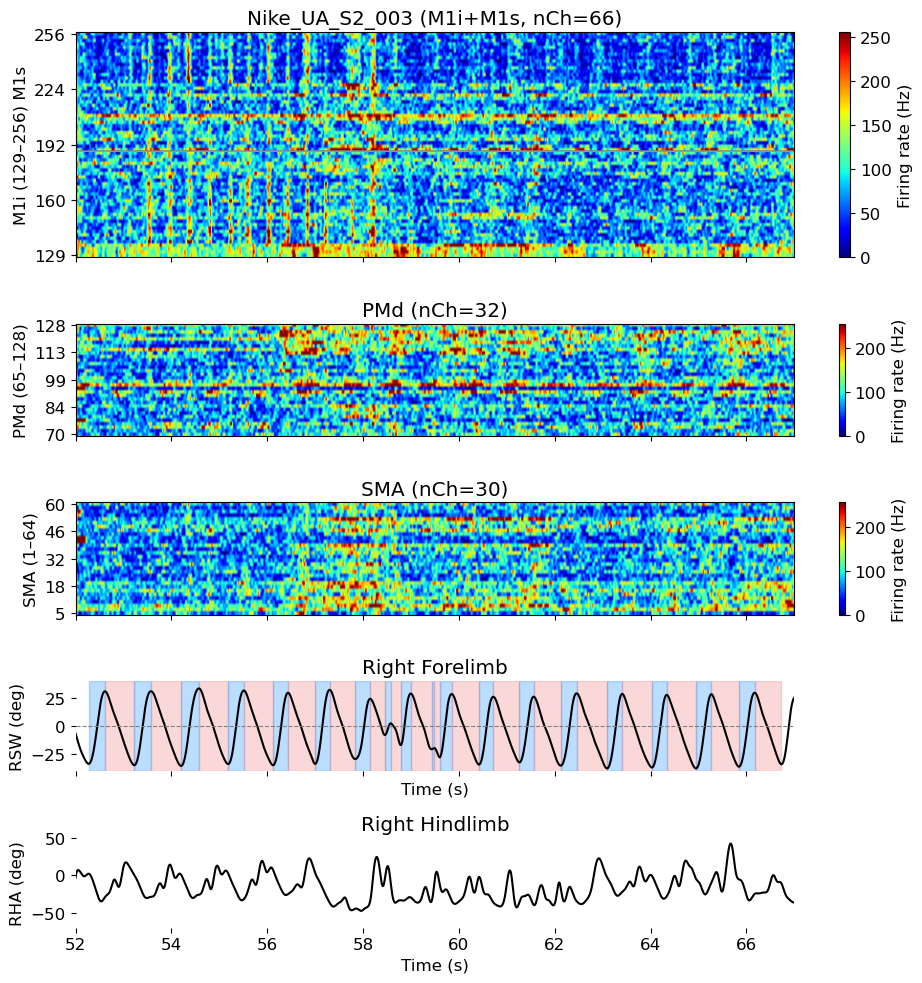

In [53]:
# ---------------------------------------------------------------------
# Three UA-region heatmaps in ONE figure with custom height ratios
# + M1i/M1s boundary + electrode-range labels + impedance masking
# ---------------------------------------------------------------------
import numpy as np
import h5py, re, csv
import matplotlib.pyplot as plt
from pathlib import Path

# -------- window (in seconds) --------
T_START_S = 52.0      # start time of the window (s)
WIN_LEN_S = 15.0      # length of the window (s)

with METADATA_CSV.open("r", newline="") as f:
    rdr = csv.DictReader(f)
    if not rdr.fieldnames:
        print(f"[WARN] {METADATA_CSV.name} has no header")
    elif "BR_File" not in rdr.fieldnames or "UA_port" not in rdr.fieldnames:
        print(f"[WARN] metadata missing BR_File and/or UA_port columns (have: {rdr.fieldnames})")
    else:
        for row in rdr:
            try:
                if int(row["BR_File"]) == br_idx:
                    ua_port = (row["UA_port"] or "") or None
                    break
            except Exception:
                continue
            
T_START_MS = T_START_S * 1000.0
T_END_MS   = (T_START_S + WIN_LEN_S) * 1000.0

IMP_BASE = OUT_BASE.parents[1] / "Nike_UA_S2"
IMP_FILES = {
    "A": IMP_BASE / "Impedances" / "bank_A_imp",
    "B": IMP_BASE / "Impedances" / "bank_B_imp",
}

UA_IMP_MAX_KOHM = 1000.0
EXCLUDE_UA_HIGH_Z = True

_imp_pat_elecnum = re.compile(
    r"\belec\s*\d+\s*-\s*(\d{1,3})\s+"          # elecX-### column
    r"(?:<=\s*|≤\s*)?"                          # optional '<=' OR Unicode '≤'
    r"([0-9]+(?:\.[0-9]+)?)\s*"                 # numeric value (e.g. 15, 15.0)
    r"(k?ohms?|kΩ|ohms?|Ω)\b",                  # unit: kOhm, Ohm, kΩ, Ω
    flags=re.IGNORECASE,
)


def _unit_to_kohm(val: float, unit: str) -> float:
    u = (unit or "").lower()
    if "k" in u:
        return float(val)
    return float(val) / 1000.0  # Ω → kΩ

def _read_text_loose(p: Path) -> str:
    if not p.exists():
        raise FileNotFoundError(str(p))
    b = p.read_bytes()
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1", "mac_roman"):
        try:
            return b.decode(enc)
        except Exception:
            pass
    filtered = bytes(ch for ch in b if 9 <= ch <= 126 or ch in (10, 13))
    return filtered.decode("latin-1", errors="ignore")

def load_impedances_from_textedit_dump(path_like: str | Path) -> dict[int, float]:
    """
    Parse lines like 'elec1-5   201 kOhm' from a loose text dump.
    Returns { Elec#: impedance_kΩ }.
    """
    txt = _read_text_loose(Path(path_like))
    out: dict[int, float] = {}
    for m in _imp_pat_elecnum.finditer(txt):
        elec_str, val_str, unit = m.groups()
        try:
            elec = int(elec_str)
            val = float(val_str)
        except Exception:
            continue
        out[elec] = _unit_to_kohm(val, unit)
    return out

def make_ua_keep_mask_from_imp(ua_ids_1based, imp_by_elec, max_kohm):
    """
    Build a boolean mask of UA rows to keep.

    Policy:
      - If an electrode has a measured impedance <= max_kohm, keep it.
      - If impedance is > max_kohm, drop it.
      - If there is NO impedance entry for that electrode, drop it.
    """
    ids_arr = np.asarray(ua_ids_1based, float).ravel()
    keep = np.ones(ids_arr.size, dtype=bool)

    n_matched = 0
    n_highZ   = 0
    n_missing = 0

    for r, eid in enumerate(ids_arr):
        if not np.isfinite(eid):
            # no usable electrode id → drop
            keep[r] = False
            n_missing += 1
            continue

        z = imp_by_elec.get(int(eid))
        if z is None or not np.isfinite(z):
            # no impedance entry → drop
            keep[r] = False
            n_missing += 1
            continue

        n_matched += 1
        if z > max_kohm:
            keep[r] = False
            n_highZ += 1

    print(
        f"[imp mask] matched={n_matched}, "
        f"highZ(>{max_kohm} kΩ)={n_highZ}, "
        f"missing_or_nan={n_missing}, "
        f"kept={keep.sum()}/{keep.size}"
    )

    if not keep.any():
        print("[warn] UA: impedance mask removed all rows; skipping mask.")
        return None

    return keep

# --- build impedance dict once (reuse same IMP_FILES + loader) ---
imp_by_elec = {}

p = IMP_FILES.get(ua_port)
if not p:
    print(f"[warn] UA impedance path missing for port {ua_port} in IMP_FILES.")
else:
    if not p.exists():
        print(f"[warn] UA impedance file not found for port {ua_port}: {p}")
    else:
        try:
            d = load_impedances_from_textedit_dump(p)
            imp_by_elec.update(d)
            print(f"[info] Parsed {len(d)} UA impedances from {p.name} (port {ua_port}).")
        except Exception as e:
            print(f"[warn] could not parse UA impedances from {p} (port {ua_port}): {e}")


# --- apply impedance mask on FULL UA arrays first -------------------
if EXCLUDE_UA_HIGH_Z and imp_by_elec:
    ua_keep_mask = make_ua_keep_mask_from_imp(ua_elec, imp_by_elec, UA_IMP_MAX_KOHM)
    if ua_keep_mask is not None:
        ua_keep_mask = np.asarray(ua_keep_mask, bool)
        rate_hz  = rate_hz[ua_keep_mask, :]   # <--- full time axis
        UA_probe = np.asarray(UA_probe)[ua_keep_mask]
        ua_elec  = np.asarray(ua_elec)[ua_keep_mask]
        print(f"[info] UA long window: kept {ua_keep_mask.sum()}/{ua_keep_mask.size} rows (≤ {UA_IMP_MAX_KOHM:g} kΩ).")

# -------- now pick time window (AFTER masking channels) -------------
time_mask = (t_cat_ms >= T_START_MS) & (t_cat_ms <= T_END_MS)
if not np.any(time_mask):
    print(f"No bins in requested window [{T_START_S}, {T_START_S + WIN_LEN_S}] s")
else:
    t_plot_ms = t_cat_ms[time_mask]
    t_plot_s  = t_plot_ms / 1000.0
    rate_win  = rate_hz[:, time_mask]

    ua_regions  = np.asarray(UA_probe, int)
    ua_elec_arr = np.asarray(ua_elec)   # 1-based electrode IDs, same order as UA_probe

    if ua_regions.size != rate_win.shape[0]:
        print("[WARN] UA_probe length != #channels in rate_win; cannot split by region.")
    elif ua_elec_arr.size != rate_win.shape[0]:
        print("[WARN] ua_elec length != #channels in rate_win; cannot use electrode labels.")
        ua_elec_arr = None
    else:
        # global color range
        vmin_global = 0.0
        if np.isfinite(rate_win).any():
            vmax_global = np.nanpercentile(rate_win, 99.0)
        else:
            vmax_global = 1.0

        # region codes: 0=SMA, 1=PMd, 2=M1 inf, 3=M1 sup
        region_groups = [
            ("M1i+M1s", [2, 3]),
            ("PMd",     [1]),
            ("SMA",     [0]),
        ]

        # ---- build matrices for each group first ----
        group_mats = []  # list of (label, rate_g, regs_g, elec_g)
        for group_label, codes in region_groups:
            mask = np.isin(ua_regions, codes)
            n_ch = int(mask.sum())
            if n_ch == 0:
                print(f"[INFO] No channels in group {group_label}; skipping.")
                continue

            rate_g = rate_win[mask, :]
            regs_g = ua_regions[mask]
            elec_g = ua_elec_arr[mask] if ua_elec_arr is not None else None

            # stable sort within group by region code then electrode ID
            if elec_g is not None:
                sort_order = np.lexsort((elec_g, regs_g))
            else:
                sort_order = np.argsort(regs_g, kind="stable")

            rate_g = rate_g[sort_order, :]
            regs_g = regs_g[sort_order]
            elec_g = elec_g[sort_order] if elec_g is not None else None

            group_mats.append((group_label, rate_g, regs_g, elec_g))

        if not group_mats:
            print("[INFO] No UA channels in any group; nothing to plot.")
        else:
            n_panels = len(group_mats)

           

            # ---- Define height ratios for subplot layout ----
            height_ratios = []
            for label, _, _, _ in group_mats:
                if label == "M1i+M1s":
                    height_ratios.append(2.0)  # taller for M1i+M1s
                else:
                    height_ratios.append(1.0)
            # Add bottom panels: RSW and RHA
            height_ratios.append(0.8)  # RSW panel height
            height_ratios.append(0.8)  # RHA panel height

            fig, axes = plt.subplots(
                n_panels + 2, 1,
                figsize=(10, 2 * (n_panels + 2)),
                sharex=True,
                gridspec_kw={"height_ratios": height_ratios},
            )

            # Ensure axes slicing is consistent with subplot arrangement
            axes = list(np.atleast_1d(axes))
            ua_axes = axes[:-2]  # UA rate group axes
            ax_RSW = axes[-2]    # RSW trace panel
            ax_RHA = axes[-1]    # RHA trace panel

            ua_im = None  # Placeholder for last UA imshow (colorbar)

            # ---- Plot UA (rate) panels ----
            for ax, (group_label, rate_g, regs_g, elec_g) in zip(ua_axes, group_mats):
                n_ch = rate_g.shape[0]

                ua_im = ax.imshow(
                    rate_g,
                    aspect="auto",
                    origin="lower",
                    extent=[t_plot_s[0], t_plot_s[-1], 0, n_ch],
                    cmap="jet",
                    vmin=vmin_global,
                    vmax=vmax_global,
                )

                # Set y-axis ticks for electrode IDs or region codes
                if elec_g is not None and elec_g.size == n_ch:
                    elec_min = int(np.nanmin(elec_g))
                    elec_max = int(np.nanmax(elec_g))
                    n_ticks = min(5, n_ch)
                    yticks = np.linspace(0.5, n_ch - 0.5, n_ticks)
                    ylabels = np.linspace(elec_min, elec_max, n_ticks).astype(int)
                    ax.set_yticks(yticks)
                    ax.set_yticklabels(ylabels)
                else:
                    ax.set_yticks([])

                # Set labels and titles
                ax.set_xlim(T_START_S, T_START_S + WIN_LEN_S)
                if ax is ua_axes[0]:
                    ax.set_title(f"{FILE.name} ({group_label}, nCh={n_ch})")
                else:
                    ax.set_title(f"{group_label} (nCh={n_ch})")

                if group_label == "SMA":
                    ax.set_ylabel("SMA (1–64)")
                elif group_label == "PMd":
                    ax.set_ylabel("PMd (65–128)")
                elif group_label == "M1i+M1s":
                    ax.set_ylabel("M1i (129–256) M1s")
                else:
                    ax.set_ylabel(group_label)

                # Separator lines for regions
                unique_regs, reg_start_idx = np.unique(regs_g, return_index=True)
                for y in reg_start_idx[1:]:
                    ax.axhline(y, color="white", linewidth=0.8, alpha=0.7)

                if group_label == "M1i+M1s" and "regs_g" in locals():
                    is_inf = (regs_g == 2)  # Region code 2 = M1i
                    inf_count = int(np.count_nonzero(is_inf))
                    if 0 < inf_count < n_ch:
                        ax.axhline(inf_count, color="0.5", linewidth=1.2, alpha=0.9)

                cbar = plt.colorbar(ua_im, ax=ax)
                cbar.set_label("Firing rate (Hz)")

            # ---- Bottom panels for RSW and RHA traces ----
            rsw_path = IMP_BASE / "Nike_UA_S2_003_BR.mat"
            fs_RSW = 1000  # Sampling rate for RSW (Hz)
            ylim_rsw = [-40, 40]  # Set custom Y-axis limits for RSW (example: [-5, 5])
            ylim_rha = [-70, 50]  # Set custom Y-axis limits for RHA (example: [-2, 2])
            with h5py.File(rsw_path, "r") as f:
                RSW = f["Data"]["RSW"][0, :]
                RHA = f["Data"]["RHA"][0, :]

            # Align time axis to main UA time span
            t_rsw = np.arange(RSW.size) / fs_RSW
            t_rha = np.arange(RHA.size) / fs_RSW
            start_idx_rsw = int(T_START_S * fs_RSW)  # Synchronize start time
            end_idx_rsw = int((T_START_S + WIN_LEN_S) * fs_RSW)
            RSW = RSW[start_idx_rsw:end_idx_rsw]
            RHA = RHA[start_idx_rsw:end_idx_rsw]
            t_rsw = t_rsw[start_idx_rsw:end_idx_rsw]
            t_rha = t_rha[start_idx_rsw:end_idx_rsw]

            # RSW trace panel
                    # ---- 1. find max and min ----
            ua_peaks_ms, _ = find_peaks(RSW)  
            troughs, _ = find_peaks(-RSW)  
            extrema = np.sort(np.concatenate([ua_peaks_ms, troughs]))  # combine and sort

            # ---- 2. background color ----
            for i in range(len(extrema) - 1):
                start_idx = extrema[i]
                end_idx = extrema[i + 1]
                
                # range
                if RSW[start_idx] < RSW[end_idx]:
                    color = 'dodgerblue'  # max to min -blue
                else:
                    color = 'lightcoral'  # min to max -pink
                
                
                ax_RSW.axvspan(t_rsw[start_idx], t_rsw[end_idx], color=color, alpha=0.3)  # adjust

            # ---- 3. 绘制 RSW trace ----
            ax_RSW.plot(t_rsw, RSW, color="black", linewidth=1.5, label="RSW trace")  # RSW trace color

            # ---- 4.  reference line
            ax_RSW.axhline(0, color='gray', linestyle='--', linewidth=0.8)
            ax_RSW.set_xlim(T_START_S, T_START_S + WIN_LEN_S)

            if ylim_rsw is not None:
                ax_RSW.set_ylim(ylim_rsw)  # 设置限定的 y 轴范围
            else:
                ax_RSW.relim()
                ax_RSW.autoscale()

            ax_RSW.set_xlabel("Time (s)")
            ax_RSW.set_ylabel("RSW (deg)")
            ax_RSW.set_title("Right Forelimb")
            for spine in ax_RHA.spines.values():
                spine.set_visible(False)
                ax_RHA.grid(False)
            ax_RSW.spines['top'].set_visible(False)   # 隐藏上边
            ax_RSW.spines['right'].set_visible(False)  # 隐藏右边
            ax_RSW.spines['left'].set_visible(False)   # 隐藏上边
            ax_RSW.spines['bottom'].set_visible(False)  # 隐藏右边
            # RHA trace panel
            ax_RHA.plot(t_rha, RHA, color="k", linewidth=1.5)
            ax_RHA.set_xlim(T_START_S, T_START_S + WIN_LEN_S)
            ax_RHA.set_ylabel("RHA (deg)")
            ax_RHA.set_xlabel("Time (s)")
            ax_RHA.set_title("Right Hindlimb")
            for spine in ax_RHA.spines.values():
                spine.set_visible(False)
                ax_RHA.grid(False)
            if ylim_rha is not None:  # Apply custom Y-axis limits if provided
                ax_RHA.set_ylim(ylim_rha)
            else:
                ax_RHA.relim()  # Auto-scale if no limits are provided
                ax_RHA.autoscale()
            # Align layout
            if ua_im is not None:
                cb_dummy_rsw = plt.colorbar(ua_im, ax=ax_RSW)
                cb_dummy_rsw.ax.set_visible(False)
                cb_dummy_rha = plt.colorbar(ua_im, ax=ax_RHA)
                cb_dummy_rha.ax.set_visible(False)

            plt.tight_layout()
            plt.show()

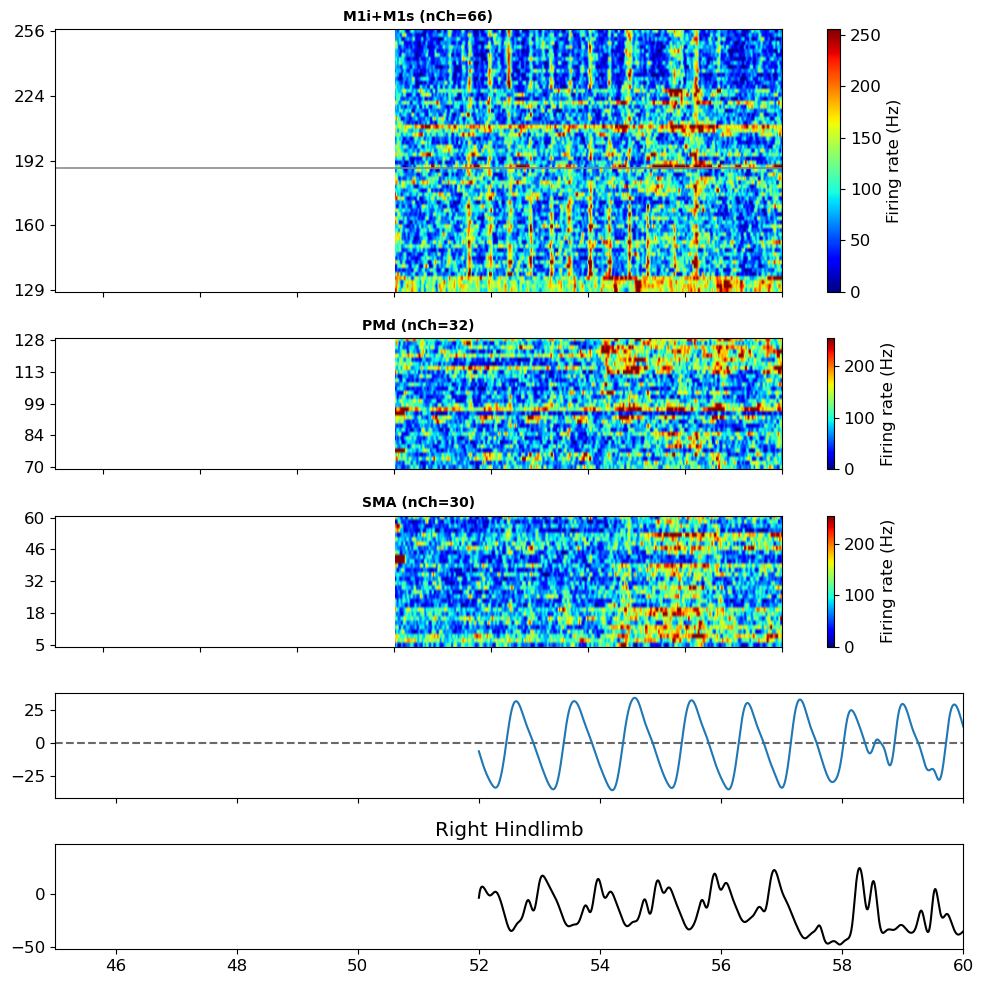

In [66]:

# -------- window (in seconds) --------
T_START_S = 45.0      # start time of the window (s)
WIN_LEN_S = 15.0      # length of the window (s)

# Metadata and setup --- Load as per your details

# Add your previous code here for loading data, impedance masking, etc.

# ------ Generate plots ------
# Three UA-region heatmaps + RSW/RHA traces
if not group_mats:  # If no data in chosen UA group.
    print("[INFO] No UA channels in any group; nothing to plot.")
else:
    n_panels = len(group_mats)

    # Define height ratios
    height_ratios = [2.0 if l == "M1i+M1s" else 1.0 for l, _, _, _ in group_mats]
    height_ratios += [0.8, 0.8]  # Add space for RSW and RHA panels

    fig, axes = plt.subplots(
        n_panels + 2, 1,
        figsize=(10, 2 * (n_panels + 2)),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios},
    )

    axes = list(np.atleast_1d(axes))
    ua_axes = axes[:-2]  # Subplots for UA heatmaps
    ax_RSW = axes[-2]    # Trace plot panel for RSW
    ax_RHA = axes[-1]    # Trace plot panel for RHA

    ua_im = None  # Placeholder for the colorbar from imshow

    # ---- Plot UA heatmaps ----
    for ax, (group_label, rate_g, regs_g, elec_g) in zip(ua_axes, group_mats):
        n_ch = rate_g.shape[0]

        ua_im = ax.imshow(
            rate_g,
            aspect="auto",
            origin="lower",
            extent=[t_plot_s[0], t_plot_s[-1], 0, n_ch],
            cmap="jet",  # Colormap
            vmin=vmin_global,
            vmax=vmax_global,
        )

        ax.set_xlim(T_START_S, T_START_S + WIN_LEN_S)

        # Configure Y-axis labels (based on electrode IDs or regions)
        if elec_g is not None and elec_g.size == n_ch:
            elec_min = int(np.nanmin(elec_g))
            elec_max = int(np.nanmax(elec_g))
            yticks = np.linspace(0.5, n_ch - 0.5, min(5, n_ch))
            ylabels = np.linspace(elec_min, elec_max, len(yticks)).astype(int)
            ax.set_yticks(yticks)
            ax.set_yticklabels(ylabels)
        else:
            ax.set_yticks([])

        ax.set_title(
            f"{group_label} (nCh={n_ch})", fontsize=10, weight="bold"
        )

        ax.axhline(0, color="white", linewidth=0.8, alpha=0.7)  # M1 boundary lines

        if group_label == "M1i+M1s":
            inf_region = regs_g == 2  # Example for M1i
            if 0 < np.count_nonzero(inf_region) < n_ch:
                ax.axhline(
                    inf_region.sum(), color="gray", linewidth=1.2, alpha=0.9
                )

        # Individual colorbars for each panel
        plt.colorbar(ua_im, ax=ax).set_label("Firing rate (Hz)")

    # ---- Plot RSW panel ----
    rsw_path = IMP_BASE / "Nike_UA_S2_003_BR.mat"  # Example path
    fs_RSW = 1000  # Sampling frequency for alignment

    with h5py.File(rsw_path, "r") as f:
        RSW = f["Data"]["RSW"][0, :]
        RHA = f["Data"]["RHA"][0, :]

    # Extract window's data and time alignment
    t_rsw = (np.arange(start_idx_rsw, end_idx_rsw) / fs_RSW)
    t_rha = (np.arange(start_idx_rsw, end_idx_rsw) / fs_RSW)
    RSW = RSW[start_idx_rsw:end_idx_rsw]
    RHA = RHA[start_idx_rsw:end_idx_rsw]

    ax_RSW.axhline(0, color="dimgray", linestyle="--")
    ax_RSW.plot(t_rsw, RSW, label="RSW trace", linewidth=1.5)

    ax_RHA.plot(t_rha, RHA, color="k", linewidth=1.5)
    ax_RHA.set_title("Right Hindlimb")
    ax_RHA.set_xlim(T_START_S, T_START_S + WIN_LEN_S)

    plt.tight_layout()
    plt.show()


GENERATING AVERAGE GAIT CYCLE PLOT (fs_UA=50Hz, fs_RSW=1kHz)...
[INFO] Found 55 valid gait cycles.
[INFO] Neural data: 128 channels, 26079 time bins @ 50 Hz.


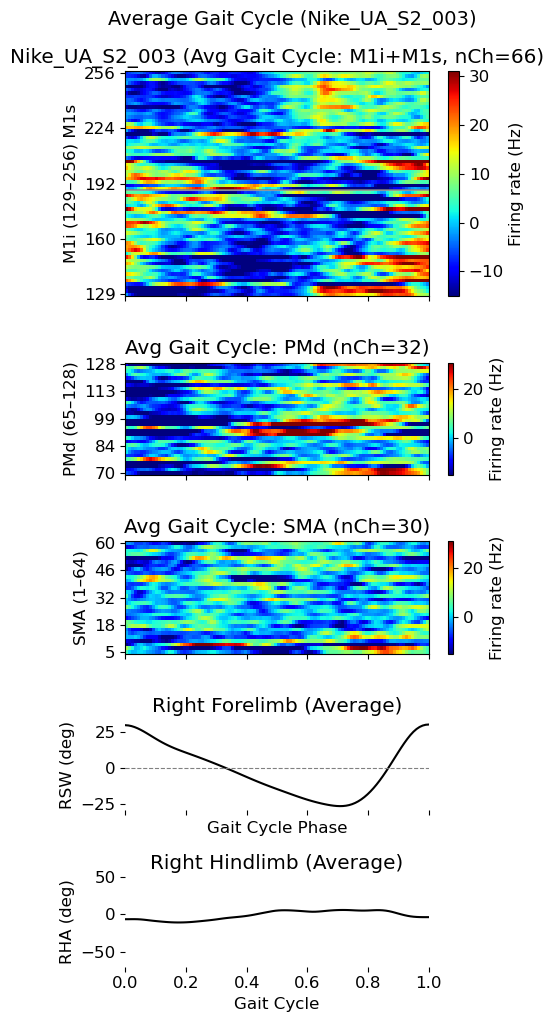

In [62]:
# ---------------------------------------------------------------------
# SECOND FIGURE: Average Gait Cycle Heatmaps & Traces (FINAL - fs_UA=50Hz)
# Assumptions:
#   - RSW/RHA/TM_11: fs = 1000 Hz, time starts at 0s.
#   - Neural data (`rate_hz`): fs = 50 Hz, time also starts at 0s.
# ---------------------------------------------------------------------

print("\n" + "="*80)
print("GENERATING AVERAGE GAIT CYCLE PLOT (fs_UA=50Hz, fs_RSW=1kHz)...")
print("="*80)

# --- Define sampling rates ---
fs_RSW = 1000       # Hz, for RSW, RHA, and TM_11 segments
fs_UA  = 50         # Hz, for the binned neural firing rate data
rsw_path = IMP_BASE / "Nike_UA_S2_003_BR.mat"

# --- Load gait cycle segments (TM_11) and RSW/RHA data ---
with h5py.File(rsw_path, "r") as f:
    tm_11 = f["Data"]["segments"]["TM_08"][:]
    gait_start_samples_1kHz = tm_11[0, :].astype(int)
    gait_end_samples_1kHz   = tm_11[1, :].astype(int)
    
    RSW_full = f["Data"]["RSW"][0, :]
    RHA_full = f["Data"]["RHA"][0, :]

# --- Filter out invalid cycles ---
valid_cycle_mask = gait_start_samples_1kHz < gait_end_samples_1kHz
gait_start_samples_1kHz = gait_start_samples_1kHz[valid_cycle_mask]
gait_end_samples_1kHz   = gait_end_samples_1kHz[valid_cycle_mask]

if len(gait_start_samples_1kHz) == 0:
    print("[WARN] No valid gait cycles found in TM_11. Skipping average plot.")
else:
    print(f"[INFO] Found {len(gait_start_samples_1kHz)} valid gait cycles.")
    n_cycles = len(gait_start_samples_1kHz)

    # --- Create a normalized time axis for the average ---
    n_avg_points = 100
    avg_time_normalized = np.linspace(0, 1, n_avg_points)

    # --- Check if full neural data is available ---
    if 'rate_hz' not in locals() or rate_hz.size == 0:
        print("[ERROR] Full neural data (`rate_hz`) not found. Cannot plot UA heatmaps.")
        avg_group_mats = []
    else:
        n_ch_uas = rate_hz.shape[0]
        print(f"[INFO] Neural data: {n_ch_uas} channels, {rate_hz.shape[1]} time bins @ {fs_UA} Hz.")

        # --- Since both time series start at 0s, we can directly convert sample indices ---
        # Convert 1kHz gait cycle samples to time (seconds)
        gait_start_time_s = gait_start_samples_1kHz / fs_RSW
        gait_end_time_s   = gait_end_samples_1kHz / fs_RSW

        # Convert time (seconds) to 50Hz neural data sample indices
        gait_start_samples_50Hz = (gait_start_time_s * fs_UA).astype(int)
        gait_end_samples_50Hz   = (gait_end_time_s * fs_UA).astype(int)

        # --- Initialize containers for UA data ---
        ua_all_cycles = np.full((n_ch_uas, n_cycles, n_avg_points), np.nan)

        # --- Process each gait cycle for UA data ---
        for i in range(n_cycles):
            start_50 = gait_start_samples_50Hz[i]
            end_50   = gait_end_samples_50Hz[i]
            
            # Ensure indices are within bounds
            start_50 = np.clip(start_50, 0, rate_hz.shape[1])
            end_50   = np.clip(end_50, 0, rate_hz.shape[1])
            
            if end_50 <= start_50:
                continue
                
            ua_cycle = rate_hz[:, start_50:end_50]
            cycle_len = ua_cycle.shape[1]
            
            if cycle_len < 2:
                continue
                
            # Interpolate to normalized time
            t_cycle = np.linspace(0, 1, cycle_len)
            for ch in range(n_ch_uas):
                ua_all_cycles[ch, i, :] = np.interp(avg_time_normalized, t_cycle, ua_cycle[ch, :])
            
            # fig, axs = plt.subplots(1, 2)
            # axs[0].imshow(ua_all_cycles[:, i, :])
            # axs[1].imshow(ua_cycle[:, :])
            # plt.show()

        # --- Compute average UA rate ---
        ua_avg_rate = np.nanmean(ua_all_cycles, axis=1) # Shape: (n_ch, n_avg_points)
        avg_mat = np.nanmean(ua_avg_rate, axis = 1)[:, None]
        ua_avg_rate = ua_avg_rate - avg_mat
        

        # --- Apply the same impedance mask as the first figure ---
        if EXCLUDE_UA_HIGH_Z and 'ua_keep_mask' in locals() and ua_keep_mask is not None:
            ua_avg_rate = ua_avg_rate[ua_keep_mask, :]
            ua_regions_avg = np.asarray(UA_probe)[ua_keep_mask]
            ua_elec_avg    = np.asarray(ua_elec)[ua_keep_mask]
        else:
            ua_regions_avg = np.asarray(UA_probe)
            ua_elec_avg    = np.asarray(ua_elec)

        # --- Prepare UA data for plotting by region ---
        region_groups = [
            ("M1i+M1s", [2, 3]),
            ("PMd",     [1]),
            ("SMA",     [0]),
        ]
        
        avg_group_mats = []
        for group_label, codes in region_groups:
            mask = np.isin(ua_regions_avg, codes)
            n_ch = int(mask.sum())
            if n_ch == 0:
                continue

            rate_g = ua_avg_rate[mask, :]
            regs_g = ua_regions_avg[mask]
            elec_g = ua_elec_avg[mask] if ua_elec_avg is not None else None

            if elec_g is not None:
                sort_order = np.lexsort((elec_g, regs_g))
            else:
                sort_order = np.argsort(regs_g, kind="stable")

            rate_g = rate_g[sort_order, :]
            regs_g = regs_g[sort_order]
            elec_g = elec_g[sort_order] if elec_g is not None else None

            avg_group_mats.append((group_label, rate_g, regs_g, elec_g))

    # --- Average RSW and RHA (same as before) ---
    rsw_all_cycles = np.full((n_cycles, n_avg_points), np.nan)
    rha_all_cycles = np.full((n_cycles, n_avg_points), np.nan)

    for i, (start_samp, end_samp) in enumerate(zip(gait_start_samples_1kHz, gait_end_samples_1kHz)):
        rsw_cycle = RSW_full[start_samp:end_samp]
        rha_cycle = RHA_full[start_samp:end_samp]
        if len(rsw_cycle) < 2: continue
        t_cycle = np.linspace(0, 1, len(rsw_cycle))
        rsw_all_cycles[i, :] = np.interp(avg_time_normalized, t_cycle, rsw_cycle)
        rha_all_cycles[i, :] = np.interp(avg_time_normalized, t_cycle, rha_cycle)

    rsw_avg_trace = np.nanmean(rsw_all_cycles, axis=0)
    rha_avg_trace = np.nanmean(rha_all_cycles, axis=0)

    # --- Determine global color scale for UA heatmaps ---
    if avg_group_mats:
        all_rates = np.concatenate([mat[1].ravel() for mat in avg_group_mats])
        vmin_global_avg = -15
        vmax_global_avg = np.nanpercentile(all_rates, 99.0) if np.any(np.isfinite(all_rates)) else 1.0
    else:
        vmin_global_avg = -15
        vmax_global_avg = 1.0

    # --- Plotting ---
    n_avg_panels = len(avg_group_mats)
    height_ratios_avg = [2.0 if label == "M1i+M1s" else 1.0 for label, *_ in avg_group_mats] + [0.8, 0.8]

    fig_avg, axes_avg = plt.subplots(
        n_avg_panels + 2, 1,
        figsize=(5, 2 * (n_avg_panels + 2)),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios_avg},
    )

    axes_avg = list(np.atleast_1d(axes_avg))
    ua_axes_avg = axes_avg[:n_avg_panels] if n_avg_panels > 0 else []
    ax_RSW_avg = axes_avg[-2]
    ax_RHA_avg = axes_avg[-1]

    # ---- Plot UA Average Rate Panels ----
    ua_im_avg = None
    for ax, (group_label, rate_g, regs_g, elec_g) in zip(ua_axes_avg, avg_group_mats):
        n_ch = rate_g.shape[0]
        ua_im_avg = ax.imshow(
            rate_g,
            aspect="auto",
            origin="lower",
            extent=[0, 1, 0, n_ch],
            cmap="jet",
            vmin=vmin_global_avg,
            vmax=vmax_global_avg,
        )

        if elec_g is not None and elec_g.size == n_ch:
            elec_min = int(np.nanmin(elec_g))
            elec_max = int(np.nanmax(elec_g))
            n_ticks = min(5, n_ch)
            yticks = np.linspace(0.5, n_ch - 0.5, n_ticks)
            ylabels = np.linspace(elec_min, elec_max, n_ticks).astype(int)
            ax.set_yticks(yticks)
            ax.set_yticklabels(ylabels)
        else:
            ax.set_yticks([])

        ax.set_xlim(0, 1)
        if ax is ua_axes_avg[0]:
            ax.set_title(f"{FILE.stem} (Avg Gait Cycle: {group_label}, nCh={n_ch})")
        else:
            ax.set_title(f"Avg Gait Cycle: {group_label} (nCh={n_ch})")

        if group_label == "SMA":
            ax.set_ylabel("SMA (1–64)")
        elif group_label == "PMd":
            ax.set_ylabel("PMd (65–128)")
        elif group_label == "M1i+M1s":
            ax.set_ylabel("M1i (129–256) M1s")
        else:
            ax.set_ylabel(group_label)

        unique_regs, reg_start_idx = np.unique(regs_g, return_index=True)
        for y in reg_start_idx[1:]:
            ax.axhline(y, color="white", linewidth=0.8, alpha=0.7)

        if group_label == "M1i+M1s":
            is_inf = (regs_g == 2)
            inf_count = int(np.count_nonzero(is_inf))
            if 0 < inf_count < n_ch:
                ax.axhline(inf_count, color="0.5", linewidth=1.2, alpha=0.9)

        cbar = plt.colorbar(ua_im_avg, ax=ax)
        cbar.set_label("Firing rate (Hz)")

    # ---- Plot Average RSW/RHA Traces ----
    ax_RSW_avg.plot(avg_time_normalized, rsw_avg_trace, color="black", linewidth=1.5)
    ax_RSW_avg.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax_RSW_avg.set_xlim(0, 1)
    ax_RSW_avg.set_xlabel("Gait Cycle Phase")
    ax_RSW_avg.set_ylabel("RSW (deg)")
    ax_RSW_avg.set_title("Right Forelimb (Average)")
    for spine in ax_RSW_avg.spines.values(): spine.set_visible(False)
    ax_RSW_avg.grid(False)

    ax_RHA_avg.plot(avg_time_normalized, rha_avg_trace, color="k", linewidth=1.5)
    ax_RHA_avg.set_xlim(0, 1)
    ax_RHA_avg.set_ylabel("RHA (deg)")
    ax_RHA_avg.set_xlabel("Gait Cycle")
    ax_RHA_avg.set_title("Right Hindlimb (Average)")
    for spine in ax_RHA_avg.spines.values(): spine.set_visible(False)
    ax_RHA_avg.grid(False)
    if 'ylim_rha' in locals(): ax_RHA_avg.set_ylim(ylim_rha)

    if ua_im_avg is not None:
        for ax_bottom in [ax_RSW_avg, ax_RHA_avg]:
            cb_dummy = plt.colorbar(ua_im_avg, ax=ax_bottom)
            cb_dummy.ax.set_visible(False)

    plt.tight_layout()
    plt.suptitle(f"Average Gait Cycle ({FILE.stem})", fontsize=14, y=1.02)
    plt.show()